In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import geopandas as gpd

#establish DB connection
import os
from sqlalchemy import create_engine

USERNAME = os.getenv('USERNAME')
PASSWORD = os.getenv('PASSWORD')
HOSTNAME = os.getenv('HOSTNAME')
PORT = 3306
DATABASE = 'ufo_sightings_db'
engine = create_engine(f'mysql+pymysql://{USERNAME}:{PASSWORD}@{HOSTNAME}:{PORT}/{DATABASE}')

<div style="font-size:20px;">
Geographical Analysis
</div>

1. SQL Query to find Top 10 Sightings by State

SELECT state_province, COUNT(\*)<br/>
FROM ufo_sightings <br/>
GROUP BY state_province <br/>
ORDER BY COUNT(\*) DESC LIMIT 10;

2. SQL Query to find Top 10 Sightings by City


SELECT city, COUNT(\*) <br/>
FROM ufo_sightings <br/>
GROUP BY city <br/>
ORDER BY COUNT(\*) DESC LIMIT 10;

In [108]:
# Query for states
query_state = "SELECT state_province, COUNT(*) FROM ufo_sightings GROUP BY state_province ORDER BY COUNT(*) DESC LIMIT 10;"
df_top_state = pd.read_sql(query_state, con=engine)
df_top_state.columns = ['state_province', 'count']

# Query for cities
query_city = "SELECT city, COUNT(*) FROM ufo_sightings GROUP BY city ORDER BY COUNT(*) DESC LIMIT 10;"
df_top_city = pd.read_sql(query_city, con=engine)
df_top_city.columns = ['city', 'count']

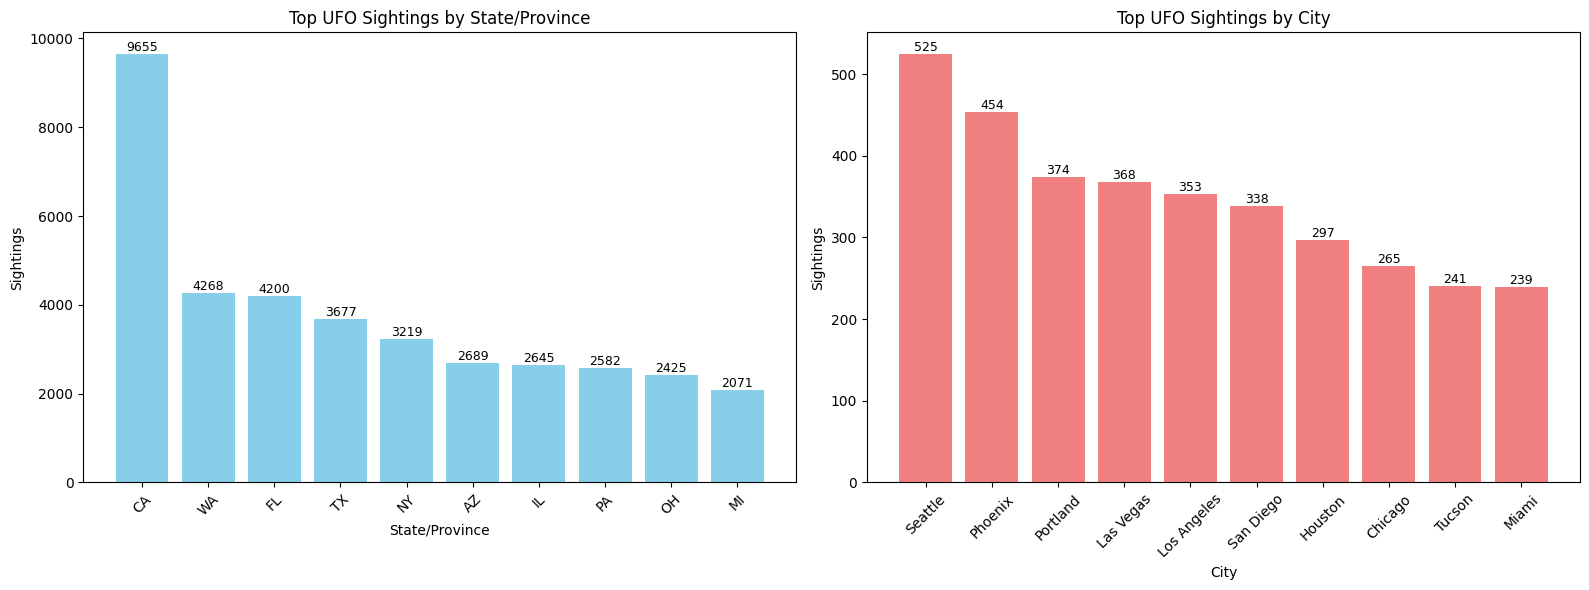

In [109]:
# Create plot for top_state and top_city analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

#1. Plot states on left
bars1 = ax1.bar(df_top_state['state_province'], df_top_state['count'], color='skyblue')
ax1.set_xlabel('State/Province')
ax1.set_ylabel('Sightings')
ax1.set_title('Top UFO Sightings by State/Province')
ax1.tick_params(axis='x', rotation=45)

# value labels for states
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height, f'{height}', 
             ha='center', va='bottom', fontsize=9)

#2. Plot cities on right
bars2 = ax2.bar(df_top_city['city'], df_top_city['count'], color='lightcoral')
ax2.set_xlabel('City')
ax2.set_ylabel('Sightings')
ax2.set_title('Top UFO Sightings by City')
ax2.tick_params(axis='x', rotation=45)

# value labels for cities
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, height, f'{height}', 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

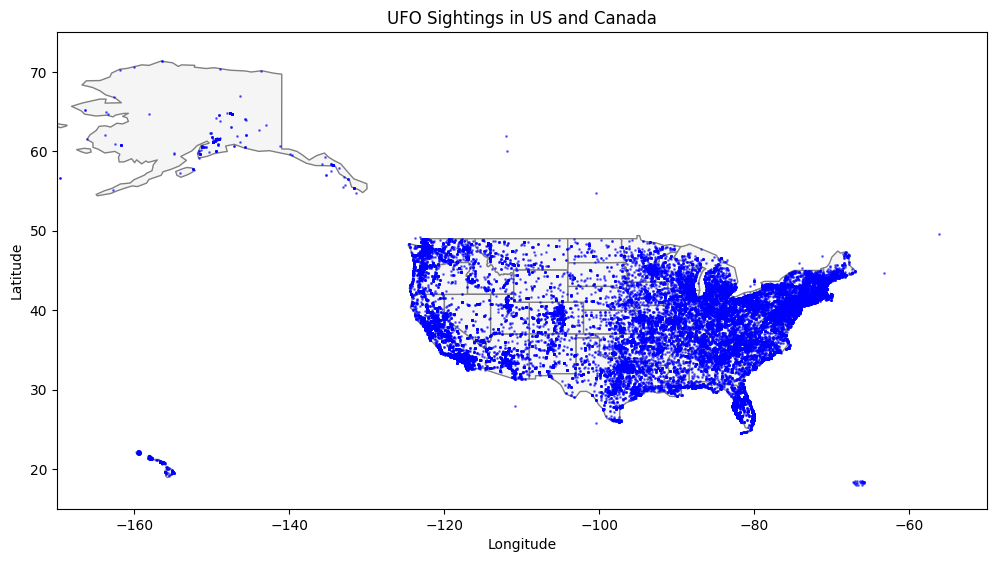

In [110]:
#plot graph for sightings distribution on map
#Reference: https://courses.cs.washington.edu/courses/cse163/24sp/2024/05/06/geospatial-data/

query = """
SELECT latitude, longitude
FROM ufo_sightings
WHERE latitude IS NOT NULL AND longitude IS NOT NULL
AND (country = 'US' OR country = 'Canada')
"""
df = pd.read_sql(query, con=engine)

shapefile_path = "./images/state_province_map/ne_110m_admin_1_states_provinces.shp"
world = gpd.read_file(shapefile_path)

# Filter to US and Canada by 'admin' column (country name)
north_america = world[world['admin'].isin(['United States of America', 'Canada'])]

gdf_points = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(12, 10))
north_america.plot(ax=ax, color='whitesmoke', edgecolor='gray')
gdf_points.plot(ax=ax, markersize=1, color='blue', alpha=0.5, marker='o')

ax.set_title("UFO Sightings in US and Canada")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Set limits for map to show only US and Canada
ax.set_xlim(-170, -50)
ax.set_ylim(15, 75)
plt.show()

Findings:
- Geographical Distribution of sightings align with human habitation, as seen with clusters in the east and west coast, but scarcity in the midwest.
- Top States/Provinces with most sightings are California, Washington, Florida, and Texas (All heavy populated states).
- Top Cities with most sightings are Seattle, Phonenix, Portland, and Las Vegas.

<div style="font-size:20px;">
Temporal Analysis
</div>

1. SQL Query to find Sightings by year:

SELECT year, COUNT(\*) as count<br/>
FROM ufo_sightings<br/> 
WHERE year IS NOT NULL<br/> 
GROUP BY year<br/>
HAVING year < 2014<br/>
ORDER BY year;

2. SQL Query to find Sightings by Day of Week:

SELECT 
    DAYNAME(date_time),
    WEEKDAY(date_time),
    COUNT(\*) as count<br/>
FROM ufo_sightings<br/> 
WHERE date_time IS NOT NULL<br/> 
GROUP BY DAYNAME(date_time), WEEKDAY(date_time)<br/>
ORDER BY WEEKDAY(date_time);

3. SQL Query to find Sightings by Month:

SELECT 
    MONTHNAME(date_time) as month_name,
    MONTH(date_time) as month,
    COUNT(\*) as count<br/>
FROM ufo_sightings <br/>
WHERE MONTHNAME(date_time) IS NOT NULL<br/>
GROUP BY MONTHNAME(date_time), MONTH(date_time)<br/>
ORDER BY MONTH(date_time) ASC;


4. SQL Query to find Sightings by Hour of Day and Season:

SELECT 
    hour,
    season,
    COUNT(\*) as count<br/>
FROM ufo_sightings<br/>
WHERE hour IS NOT NULL AND season IS NOT NULL<br/>
GROUP BY hour, season<br/>
ORDER BY hour;



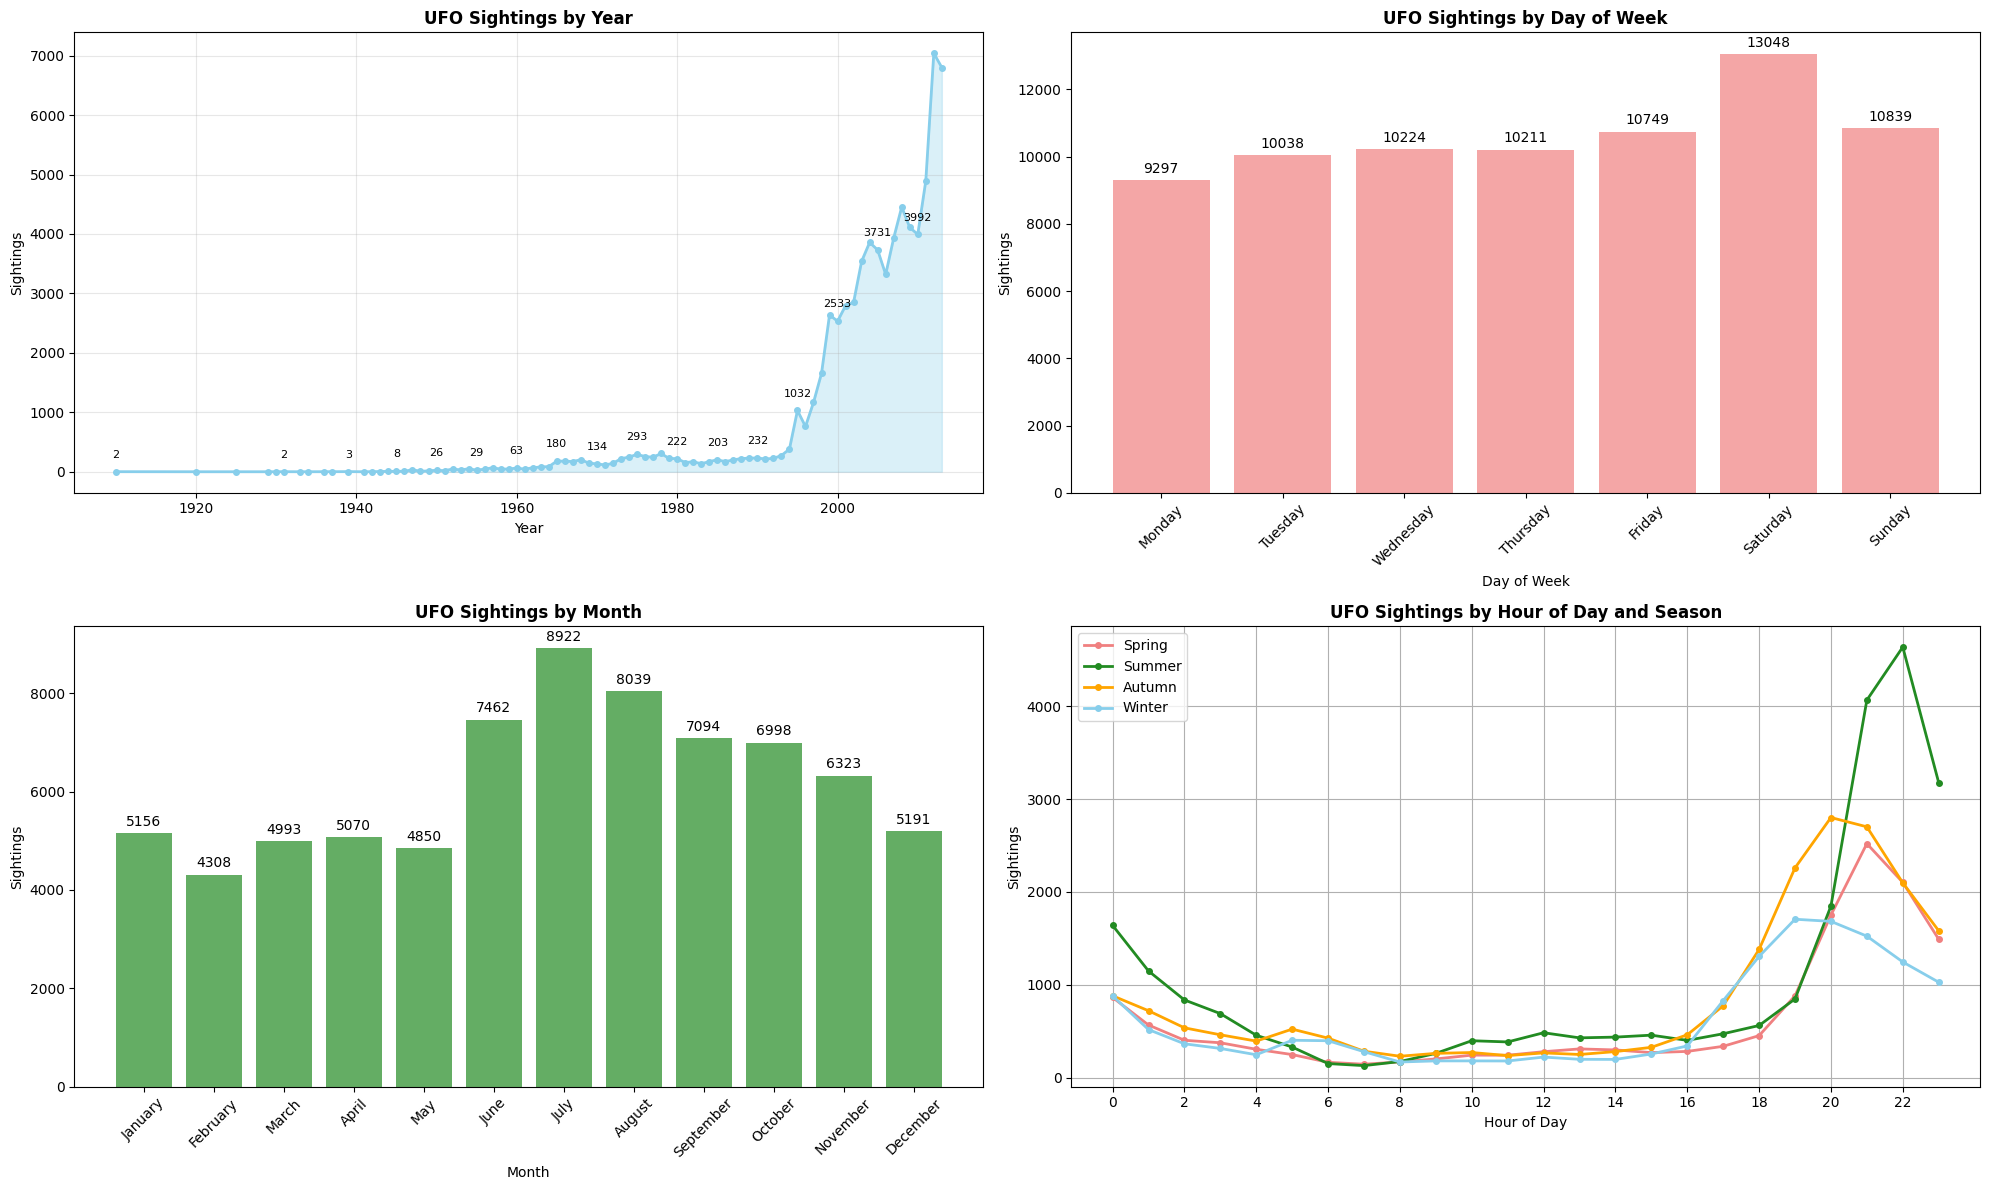

In [111]:
#Create plots for Temporal Analysis

# 1. Sightings by Year (Line graph with shaded area)
query_year = """
SELECT year, COUNT(*) as count 
FROM ufo_sightings 
WHERE year IS NOT NULL 
GROUP BY year
HAVING year < 2014
ORDER BY year;
"""
df_year = pd.read_sql(query_year, con=engine)


# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(20, 12))


#Graph for Sightings vs year
ax1 = axes[0, 0]
ax1.plot(df_year['year'], df_year['count'], marker='o', linewidth=2, markersize=4, color='skyblue')
ax1.fill_between(df_year['year'], df_year['count'], alpha=0.3, color='skyblue')
ax1.set_xlabel('Year')
ax1.set_ylabel('Sightings')
ax1.set_title('UFO Sightings by Year', fontweight='bold')
ax1.grid(True, alpha=0.3)

# Add count labels for every 5th year for better readability
for i, (year, count) in enumerate(zip(df_year['year'], df_year['count'])):
    if i % 5 == 0:  # Label every 5th year
        ax1.annotate(f'{count}', (year, count), textcoords="offset points", 
                    xytext=(0,10), ha='center', fontsize=8)


# 2. Sightings by Day of Week
query_dow = """
SELECT 
    DAYNAME(date_time),
    WEEKDAY(date_time),
    COUNT(*) as count
FROM ufo_sightings 
WHERE date_time IS NOT NULL 
GROUP BY DAYNAME(date_time), WEEKDAY(date_time)
ORDER BY WEEKDAY(date_time);
"""
df_dow = pd.read_sql(query_dow, con=engine)
df_dow.columns = ['day_of_week', 'day_num','count']


#Graph for Sightings vs day of week
ax2 = axes[0, 1]
bars = ax2.bar(df_dow['day_of_week'], df_dow['count'], color='lightcoral', alpha=0.7)
ax2.set_xlabel('Day of Week')
ax2.set_ylabel('Sightings')
ax2.set_title('UFO Sightings by Day of Week', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + max(df_dow['count'])*0.01,
            f'{height}', ha='center', va='bottom', fontsize=10)


# 3. Sightings by Month 
query_month = """
SELECT 
    MONTHNAME(date_time) as month_name,
    MONTH(date_time) as month,
    COUNT(*) as count
FROM ufo_sightings 
WHERE MONTHNAME(date_time) IS NOT NULL
GROUP BY MONTHNAME(date_time), MONTH(date_time)
ORDER BY MONTH(date_time) ASC;
"""
df_month = pd.read_sql(query_month, con=engine)
df_month.columns = ['month_name', 'month_number', 'count']



#Graph for Sightings vs Month
ax3 = axes[1, 0]
bars = ax3.bar(df_month['month_name'], df_month['count'], color='forestgreen', alpha=0.7)
ax3.set_xlabel('Month')
ax3.set_ylabel('Sightings')
ax3.set_title('UFO Sightings by Month', fontweight='bold')
ax3.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + max(df_month['count'])*0.01,
            f'{height}', ha='center', va='bottom', fontsize=10)


# 4. Sightings by Hour of Day and Season (Line graph)
query_hour_season = """
SELECT 
    hour,
    season,
    COUNT(*) as count
FROM ufo_sightings 
WHERE hour IS NOT NULL AND season IS NOT NULL
GROUP BY hour, season
ORDER BY hour;
"""
df_hour_season = pd.read_sql(query_hour_season, con=engine)
df_pivot = df_hour_season.pivot(index='hour', columns='season', values='count')


#Graph for Sightings vs Season and Hour
ax4 = axes[1, 1]
seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
colors = ['lightcoral', 'forestgreen', 'orange', 'skyblue']

for season, color in zip(seasons, colors):
    if season in df_pivot.columns:
        ax4.plot(df_pivot.index, df_pivot[season], marker='o', linewidth=2, 
                markersize=4, label=season, color=color)

ax4.set_xlabel('Hour of Day')
ax4.set_ylabel('Sightings')
ax4.set_title('UFO Sightings by Hour of Day and Season', fontweight='bold')
ax4.legend()
ax4.grid(True)
ax4.set_xticks(range(0, 24, 2))

# Adjust layout and display
plt.tight_layout()
plt.show()

Findings:
- A steady increase in sightings from 1940 to the 1990s, with a sudden exponential growth after the mid 1990s.
- Sightings peak during summer months, especially July, as well as weekends, especially Saturday and Sunday.
- It is more likely to see an UFO at night, when it is dark. This coincides with the fact that spike in sightings peak in later hours during summer, when it gets dark later.
- Warmer seasons also aligns with more sightings (Summer > Spring ~ Autumn > Winter).

<div style="font-size:20px;">
Shape Analysis
</div>

1. SQL Query to find Trend of shapes over the decades:

SELECT 
    FLOOR(year / 10) * 10 as decade,
    ufo_shape,
    COUNT(*) as count <br/>
FROM ufo_sightings <br/>
GROUP BY FLOOR(year / 10) * 10, ufo_shape<br/>
ORDER BY decade, count DESC;

2. SQL Query to find Top Shapes for sightings:

SELECT 
    ufo_shape,
    COUNT(*) as count<br/>
FROM ufo_sightings <br/>
GROUP BY ufo_shape<br/>
ORDER BY count DESC<br/>
LIMIT 10;

3. CTE Query to find the UFO Shapes that are most commonly seen as top across states/provinces

WITH ranked_shapes AS (<br/>
    SELECT <br/>
        state_province,<br/>
        ufo_shape,<br/>
        COUNT(\*) AS sightings_count,<br/>
        ROW_NUMBER() OVER (PARTITION BY state_province ORDER BY COUNT(\*) DESC) AS ranking<br/>
    FROM ufo_sightings<br/>
    WHERE ufo_shape IS NOT NULL AND state_province IS NOT NULL<br/>
    GROUP BY state_province, ufo_shape<br/>
)
SELECT state_province, ufo_shape, sightings_count<br/>
FROM ranked_shapes<br/>
WHERE ranking = 1;

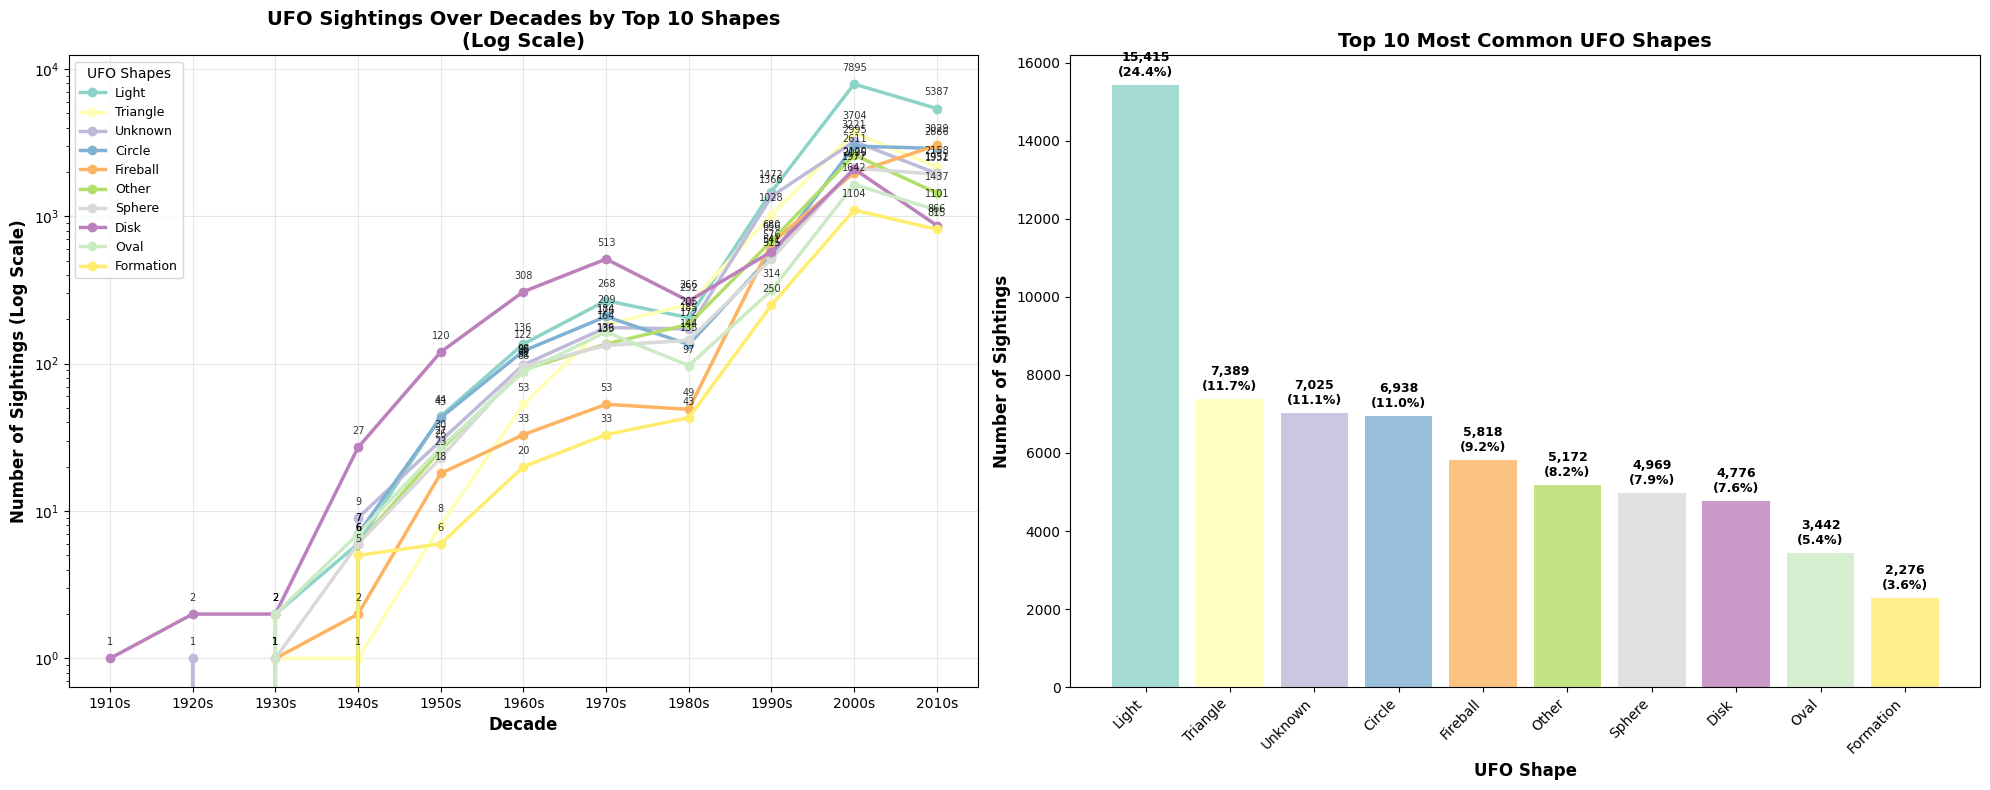

In [112]:
#Create plots for Shape Analysis

# Create 1x2 subplot layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Get the top 10 most common shapes
query_top_shapes = """
SELECT 
    ufo_shape,
    COUNT(*) as count
FROM ufo_sightings 
GROUP BY ufo_shape
ORDER BY count DESC
LIMIT 10;
"""
df_top_shapes = pd.read_sql(query_top_shapes, con=engine)
top_shapes_list = df_top_shapes['ufo_shape'].tolist()

# 1. Sightings by Decade and Top Shapes (Line graph with log scale)
query_decade_shapes = """
SELECT 
    FLOOR(year / 10) * 10 as decade,
    ufo_shape,
    COUNT(*) as count
FROM ufo_sightings 
GROUP BY FLOOR(year / 10) * 10, ufo_shape
ORDER BY decade, count DESC;
""".format(','.join([f"'{shape}'" for shape in top_shapes_list]))
df_decade_shapes = pd.read_sql(query_decade_shapes, con=engine)

# Pivot the data for easier plotting
df_pivot_decade = df_decade_shapes.pivot(index='decade', columns='ufo_shape', values='count').fillna(0)

# Define distinct colors for each shape
colors = plt.cm.Set3(np.linspace(0, 1, len(top_shapes_list)))

for i, shape in enumerate(top_shapes_list):
    if shape in df_pivot_decade.columns:
        line = ax1.plot(df_pivot_decade.index, df_pivot_decade[shape], 
                       marker='o', linewidth=2.5, markersize=6, 
                       label=shape, color=colors[i], markevery=1)
        
        # Add data labels for each decade point
        for decade, count in zip(df_pivot_decade.index, df_pivot_decade[shape]):
            ax1.annotate(f'{int(count)}', (decade, count), 
                        textcoords="offset points", xytext=(0,8), 
                        ha='center', va='bottom', fontsize=7, 
                        color='black', alpha=0.8)

ax1.set_xlabel('Decade', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Sightings (Log Scale)', fontsize=12, fontweight='bold')
ax1.set_title('UFO Sightings Over Decades by Top 10 Shapes\n(Log Scale)', 
              fontsize=14, fontweight='bold')
ax1.set_yscale('log')
ax1.legend(title='UFO Shapes', title_fontsize=10, fontsize=9, 
           loc='upper left', bbox_to_anchor=(0, 1))
ax1.grid(True, alpha=0.3)
ax1.set_xticks(df_pivot_decade.index)

# add x-axis labels for decades values
decade_labels = [f"{int(decade)}s" for decade in df_pivot_decade.index]
ax1.set_xticklabels(decade_labels)

# 2. Top 10 UFO Shapes (Bar graph with counts and percentages)
query_shapes = """
SELECT 
    ufo_shape,
    COUNT(*) as count
FROM ufo_sightings 
GROUP BY ufo_shape
ORDER BY count DESC
LIMIT 10;
"""
df_shapes = pd.read_sql(query_shapes, con=engine)

# Calculate percentages
total_sightings = df_shapes['count'].sum()
df_shapes['percentage'] = (df_shapes['count'] / total_sightings * 100).round(1)


# Create bar graph
bars = ax2.bar(df_shapes['ufo_shape'], df_shapes['count'], 
               color=plt.cm.Set3(np.linspace(0, 1, len(df_shapes))),
               alpha=0.8)

ax2.set_xlabel('UFO Shape', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Sightings', fontsize=12, fontweight='bold')
ax2.set_title('Top 10 Most Common UFO Shapes', fontsize=14, fontweight='bold')
ax2.set_xticks(range(len(df_shapes['ufo_shape'])))
ax2.set_xticklabels(df_shapes['ufo_shape'], rotation=45, ha='right')

# Add value labels on bars with both count and percentage
for bar, count, percentage in zip(bars, df_shapes['count'], df_shapes['percentage']):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + max(df_shapes['count'])*0.01,
             f'{count:,}\n({percentage}%)', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')


# Adjust layout and display
plt.tight_layout()
plt.show()


In [113]:
# Run the CTE to get the Number of states/provinces in which each shape is the most popular shape
query = """
WITH ranked_shapes AS (
    SELECT 
        state_province,
        ufo_shape,
        COUNT(*) AS sightings_count,
        ROW_NUMBER() OVER (PARTITION BY state_province ORDER BY COUNT(*) DESC) AS ranking
    FROM ufo_sightings
    WHERE ufo_shape IS NOT NULL AND state_province IS NOT NULL
    GROUP BY state_province, ufo_shape
)
SELECT state_province, ufo_shape, sightings_count
FROM ranked_shapes
WHERE ranking = 1;
"""

df_state_top_shape = pd.read_sql(query, con=engine)
print("Number of states/provinces in which each shape is the most popular shape")
df_state_top_shape['ufo_shape'].value_counts()

Number of states/provinces in which each shape is the most popular shape


ufo_shape
Light       62
Sphere       2
Triangle     2
Unknown      1
Name: count, dtype: int64

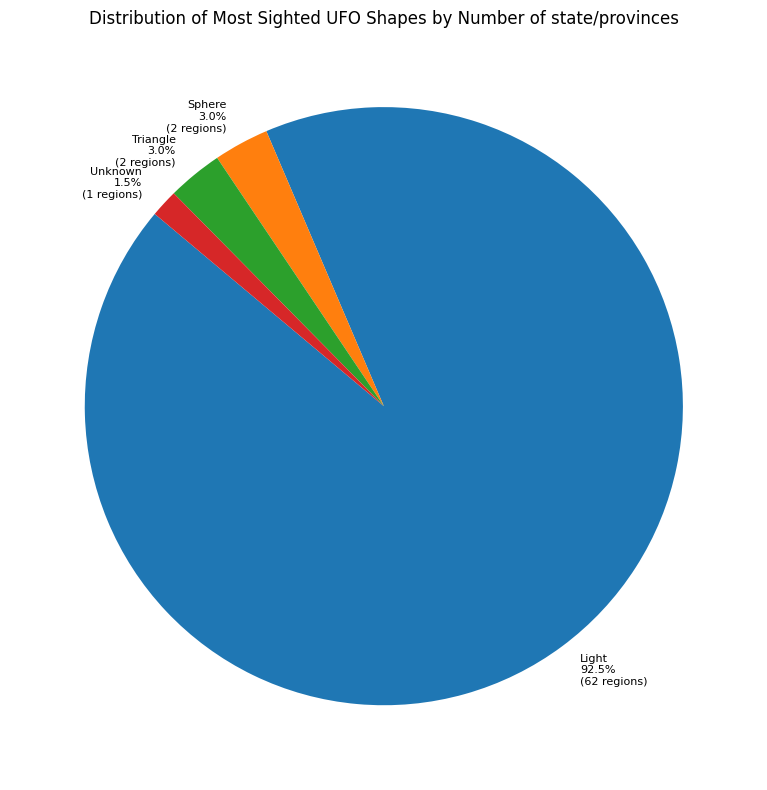

In [126]:
#graph for the Number of states/provinces in which each shape is the most popular shape

# Count how many states/provinces have each shape as most sighted
shape_counts = df_state_top_shape['ufo_shape'].value_counts().reset_index()
shape_counts.columns = ['ufo_shape', 'region_count']

# Calculate percentages
shape_counts['percentage'] = 100 * shape_counts['region_count'] / shape_counts['region_count'].sum()

#slice labels: 
labels = shape_counts.apply(
    lambda row: f"{row['ufo_shape']}\n{row['percentage']:.1f}%\n({row['region_count']} regions)", axis=1
)

# Plot pie chart
plt.figure(figsize=(10, 8))
plt.pie(
    shape_counts['region_count'],
    labels=labels,
    startangle=140,
    textprops={'fontsize': 8}
)

plt.title("Distribution of Most Sighted UFO Shapes by Number of state/provinces")
plt.tight_layout()
plt.show()

Findings:
- Looking at the shape distributions over time, we see that prior to the 1980s, dominant UFO shape sighted was "disk", but since then was overtaken by "light". 
- Overall the most common shape is "light", with over 24% of all sightings all falling into this shape category.
- A overwhelming majority of states/provinces (92.5%) report seeing Light-shaped UFOs as the most common shape, further confirming this as the prevailing shape in sightings across regions.
- A few exceptions include Sphere and Triangle, hinting of slight regional variations.

<div style="font-size:20px;">
Duration Analysis
</div>

- Looking at th boxplot of Durations, we still find a lot of values to the skewing the distribution (There are illogical values that claim of Sightings that last for hours and hours!). To get a good calculation of mean, we clip the extreme outliers (Top 25%).
- We do the following transformations consider only the bottom 75% of encounters when calculating the average length of UFO encounters:
```
cutoff = df_duration_filtered['length_of_encounter_seconds'].quantile(0.75)
df_duration_filtered = df_duration_filtered[df_duration_filtered['length_of_encounter_seconds'] <= cutoff]
```

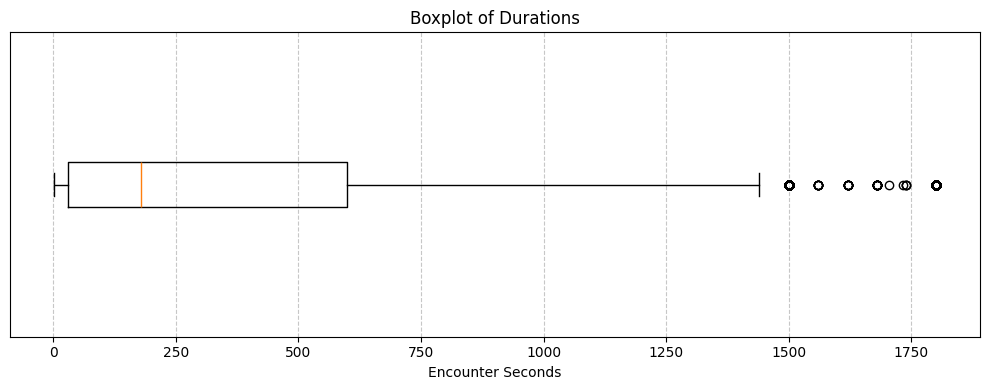

In [115]:
query = """
SELECT ufo_shape, length_of_encounter_seconds, year, hour, season
FROM ufo_sightings
"""
df_duration = pd.read_sql(query, con=engine)
# We will first get all columns needed and then perform transformation in pandas

plt.figure(figsize=(10, 4))
plt.boxplot(df_duration['length_of_encounter_seconds'], vert=False)
plt.title('Boxplot of Durations')
plt.xlabel('Encounter Seconds')
plt.yticks([])  # Hide y-axis ticks since there's only one variable
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

And use these pandas transformations to plot our graph:
```
# 1. Avg length by ufo_shape
avg_by_shape = df_duration_filtered.groupby('ufo_shape')['length_of_encounter_seconds'].mean().sort_values()

#2. Avg length by decade
avg_by_decade = df_duration_filtered.groupby('decade')['length_of_encounter_seconds'].mean().sort_index()

#3. Avg length by hour and season
avg_by_hour_season = df_duration_filtered.groupby(['hour', 'season'])['length_of_encounter_seconds'].mean().reset_index()
```

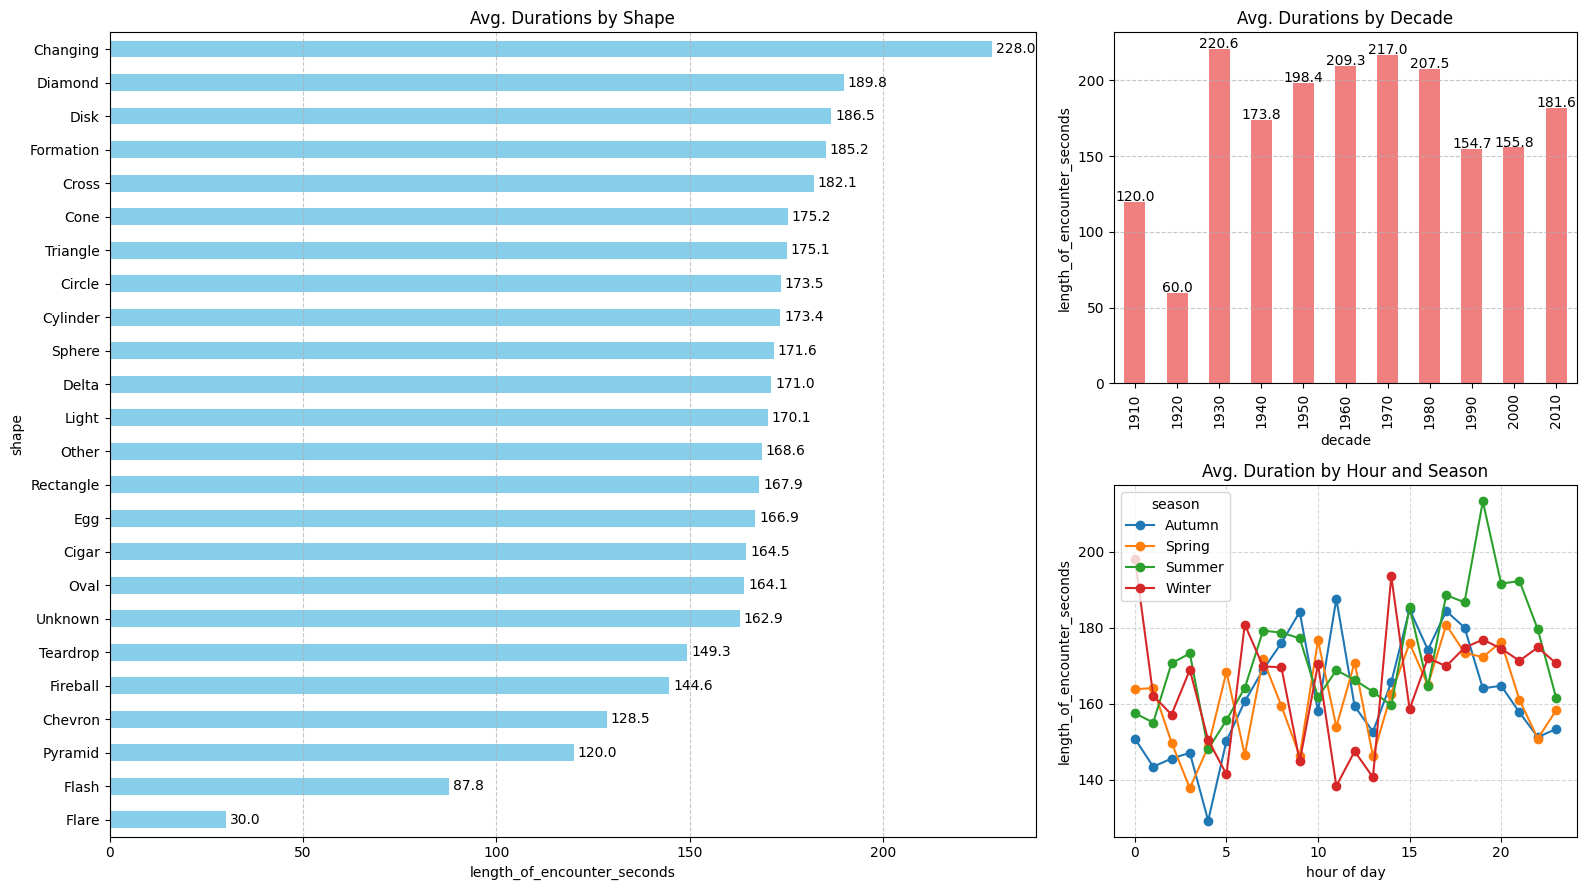

In [116]:
#plot grpahs for duration analysis

#filter out shapes that have too little appearances
df_duration_filtered = df_duration[~df_duration['ufo_shape'].isin(['Hexagon','Crescent','Round','Dome'])]

# Exclude top 25% longest encounters (overall)
cutoff = df_duration_filtered['length_of_encounter_seconds'].quantile(0.75)
df_duration_filtered = df_duration_filtered[df_duration_filtered['length_of_encounter_seconds'] <= cutoff]

# Create decade column (e.g., 1990, 2000, etc.)
df_duration_filtered['decade'] = (df_duration_filtered['year'] // 10) * 10

# 1. Avg length by ufo_shape
avg_by_shape = df_duration_filtered.groupby('ufo_shape')['length_of_encounter_seconds'].mean().sort_values()

#2. Avg length by decade
avg_by_decade = df_duration_filtered.groupby('decade')['length_of_encounter_seconds'].mean().sort_index()

#3. Avg length by hour and season
avg_by_hour_season = df_duration_filtered.groupby(['hour', 'season'])['length_of_encounter_seconds'].mean().reset_index()

# Pivot for line plot: rows=hour, columns=season, values=avg length
pivot_hour_season = avg_by_hour_season.pivot(index='hour', columns='season', values='length_of_encounter_seconds')


fig = plt.figure(figsize=(16, 9))

import matplotlib.gridspec as gridspec
gs = gridspec.GridSpec(2, 2, width_ratios=[2, 1])

# Plot 1: Avg length by ufo_shape
ax1 = fig.add_subplot(gs[:, 0])
avg_by_shape.plot(kind='barh', ax=ax1, color='skyblue')
ax1.set_xlabel('length_of_encounter_seconds')
ax1.set_ylabel('shape')
ax1.set_title('Avg. Durations by Shape')
for i, v in enumerate(avg_by_shape):
    ax1.text(v + 1, i, f"{v:.1f}", va='center')
ax1.grid(axis='x', linestyle='--', alpha=0.7)

# Plot 2: Avg length by decade
ax2 = fig.add_subplot(gs[0, 1])
avg_by_decade.plot(kind='bar', ax=ax2, color='lightcoral')
ax2.set_xlabel('decade')
ax2.set_ylabel('length_of_encounter_seconds')
ax2.set_title('Avg. Durations by Decade')
for i, v in enumerate(avg_by_decade):
    ax2.text(i, v + 0.5, f"{v:.1f}", ha='center')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Plot 3: Avg length by hour and season
ax3 = fig.add_subplot(gs[1, 1])
pivot_hour_season.plot(ax=ax3, marker='o')
ax3.set_xlabel('hour of day')
ax3.set_ylabel('length_of_encounter_seconds')
ax3.set_title('Avg. Duration by Hour and Season')
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(title='season')

plt.tight_layout()
plt.show()

- The UFO shapes that have the longest average sightings (in seconds) are "Changing" and "Cone", while the shortest ones tend to be "Flash" and "Flare".
- There seems to be no pattern of duration variation over the years, or by the time of day or season.

<div style="font-size:20px;">
Witness Description Transformation
</div>

- Transformation is done first for the description column
    * remove meaningless symbols and words that do not convey meaning
    * normalize white space
    * remove numbers and symbols enmbeded within words

In [117]:
from wordcloud import WordCloud
import nltk
import re
#installing the Vader package
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

#transform the description column to remove excess symbols/numbers/whitespace and words that do not convery meaning

query = "SELECT * FROM ufo_sightings"  # example query, limit rows for preview

df = pd.read_sql(query, con=engine)

def clean_text(comment_text):
    if pd.isna(comment_text):
        return comment_text  # keep Nan values
    # Remove symbols
    cleaned_text = re.sub(r'[@#$%^&*()_+{}[\]:;"\'<>,.~\\/\-|=]', '', comment_text)
    # Remove words that do not carry important info
    cleaned_text = re.sub(r'\b(?:and|is|in|the|on|of|to|for|a|i|my|was|at)\b', '', cleaned_text, flags=re.IGNORECASE)
    # Remove numbers
    cleaned_text = re.sub(r'\b\d+\b', '', cleaned_text)
    # Normalize whitespace
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
    # Remove special characters that appear between word characters
    cleaned_text = re.sub(r'(?<=\w)[^\w\s]+(?=\w)', '', cleaned_text)

    return cleaned_text.lower()

df['cleaned_description'] = df['description'].apply(clean_text)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/brisson/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


<div style="font-size:20px;">
Word Cloud for Witness Description</div>

- Generate a word cloud to see the most common words appearing in the description column.
- The most common words seems to be "saw", "sky", "white light", "light", "UFO", etc.

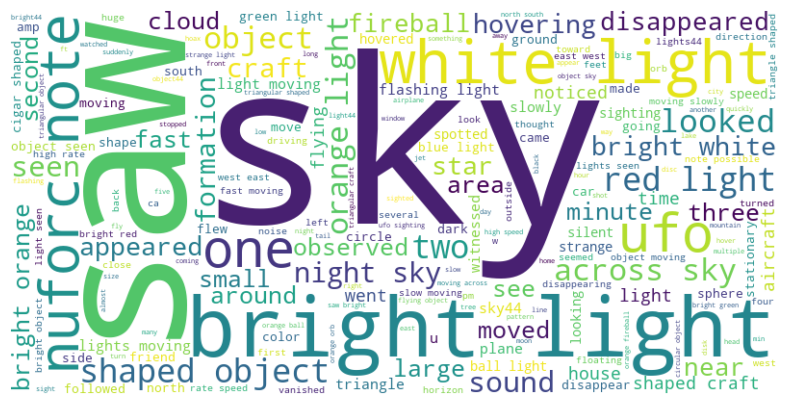

In [118]:
all_text = ' '.join(df['cleaned_description'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

<div style="font-size:20px;">
Sentiment Analysis: Getting Sentiment Score from Vader Sentiment
</div>

- We then use the Vader Sentiment Library in python to generate a sentiment polarity score for each row in the description column.
- Most positive = 1.00, Most Negative = -1.00, Neutral = 0.00

In [119]:
def get_vader_sentiment(text):
    if pd.isna(text):
        return 0.0
    text = str(text)
    scores = analyzer.polarity_scores(text)
    #score will be from -1 (most negative) to +1 (most positive)
    return scores['compound']

df['sentiment_vader'] = df['cleaned_description'].apply(get_vader_sentiment)

<div style="font-size:20px;">
Most positive and negative descriptions
</div>


- We can take a look at some of the most positively rated descriptions:
    * "visiting friends lawton everyone had gone bed sitting backyard relaxing enjoying clear warm night" (score=0.9217)
    * "beautiful night clear skies wonderful light show hope see more future" (score=0.9201)
- And the most negatively rated descriptions:
    * "Seeing believing but it scary as hell" (score=-0.8955)
    * "this so crazy felt as if we where about be attacked if not being study perfect attack" (score=-0.9136)

In [120]:
pd.set_option('display.max_colwidth', None)
print(df[['cleaned_description', 'sentiment_vader']].sort_values('sentiment_vader', ascending=False))
pd.reset_option('display.max_colwidth')

                                                                                                           cleaned_description  \
5841     ok didnt see it but heard about it hoping you could find out more friend told me that lastnight her friend seen craft   
68522  object looked liked star but it got so bright like it illuminated it scary44 it took like speed if sound44they are here   
38907                          visiting friends lawton everyone had gone bed sitting backyard relaxing enjoying clear warm nig   
49865          it very bright light kind like diamond ring glareing that did39nt blink44 ship diamond shaped made souring sort   
62288                                                  beautiful night44 clear skies wonderful light show hope see more future   
...                                                                                                                        ...   
67777                    this location not by choice but by accident this night became fig

<div style="font-size:20px;">
Kernel Density Estimate Distribution of Sentiment Scores
</div>

- Plotting a Kernel Density Estimate of Sentiment scores, we can see the approximate distuibution of Sentiment Scores. It seems that the tallest peak is at 0, indicating most descriptions are quite neutral.

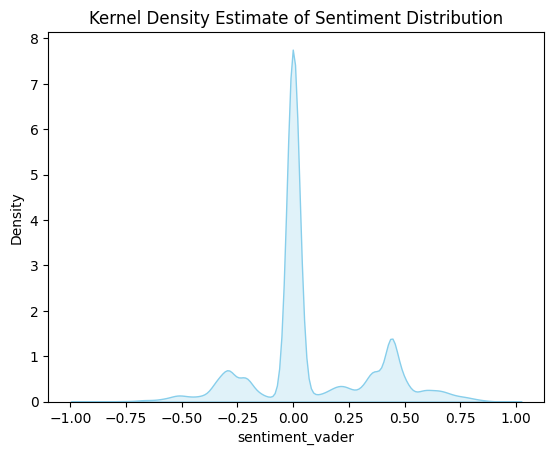

In [121]:
sns.kdeplot(df.sentiment_vader, fill=True, color='skyblue')
plt.title('Kernel Density Estimate of Sentiment Distribution')
plt.xlabel('sentiment_vader')
plt.ylabel('Density')
plt.show()

<div style="font-size:20px;">
Categorizing Witness Description as "Positive", "Neutral", "Negative"
</div>

- We then classify the scores into disdtinct categories of Positive, Neutral, and Negative, and plot a pie chart to see their percentages:
- Scores above 0.05 are considered positive sentiment. Scores below -0.05 are negative. Scores between -0.05 and 0.05 are neutral. (Boundaries come from the original VADER paper; it is a good balance to minmize the chance of having too many neutral classifications while still effectively capturing sentiment.)

In [122]:
def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_category'] = df['sentiment_vader'].apply(categorize_sentiment)

- It seems that over half (~55%) of all descriptions are classified as Neutral, while 30% of the the descriptions are classified as Positve, and around 15% of them are classified as Negative.

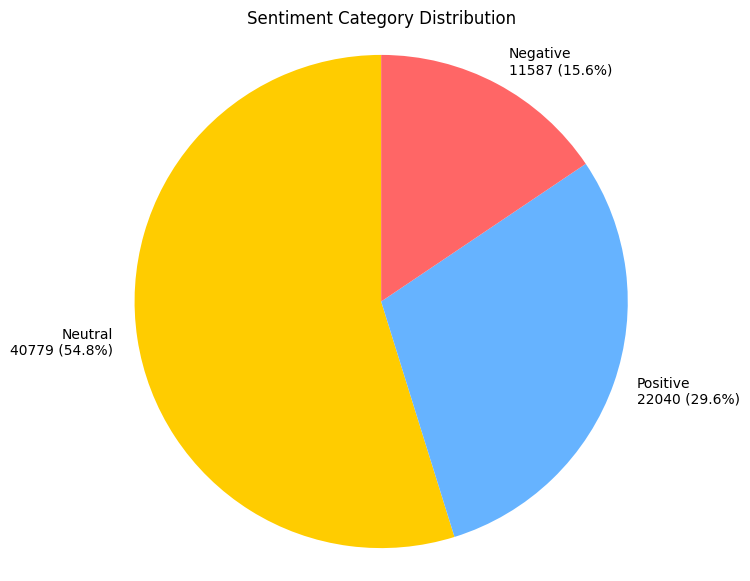

In [123]:
# Count the occurrences of each category
counts = df['sentiment_category'].value_counts()

percentages = counts / counts.sum() * 100

# # Create labels with count and percentage
labels = [f"{cat}\n{count} ({perc:.1f}%)" for cat, count, perc in zip(counts.index, counts.values, percentages.values)]

# # Plot pie chart
plt.figure(figsize=(7,7))
plt.pie(counts, labels=labels, autopct='', startangle=90, colors=['#ffcc00', '#66b3ff', '#ff6666'])
plt.title('Sentiment Category Distribution')
plt.axis('equal')
plt.show()


## Key Takeaways  

### Temporal
- You are most likely to see an UFO on a weekend night (especially Saturday) during summer, particularly July and August.
- More sightings on weekends and later hours in summer suggest correlation with human outdoor activity.
- During the mid 1990s, an inflection point is observed for UFO sightings, starting an exponential growth in sightings after long decades of steady growth.
- Increased UFO sightings since this period might have likely stemmed from a combination of factors: greater public access to the internet and media coverage popularizing UFO phenomena (ex. the X-files TV shows debuted in 1993), alongside geopolitical shifts post-Cold War that sparked curiosity and speculation, all contributing to more widespread reporting and awareness.
<br/>

### Geographical
- Geographical Distribution of sightings align with human habitation, as seen with clusters in the east and west coast, but scarcity in the midwest, indicating that population density strongly influences sighting frequency.
- Certain states, such as Texas and California, reported the highest number of sightings; this is likely due to their large populations, extensive urban and rural areas, and possibly greater media coverage or cultural interest in UFO phenomena.
- The prevalence of "Light" as the most observed shape across most states and provinces suggests that many sightings involve luminous or glowing objects, which may be easier to notice and report than specific shapes, especially during nighttime or in low-visibility conditions. It may also be the case that some individuals might mistaken man-made glowing objects (airplanes, hot air balloons) as UFOs.
<br/>

### Shape
- The most common UFO shapes reported were "Triangle", "Light", and "unknown". They make up almost half the shapes of UFO sighted.
- The dominant UFO Shape sighted has changed from "Disk" during the 1940s - 1980s, to "Light" since the 1990s. This might be due to a shift in cultural influences and media portrayal affecting witness descriptions. 
- The "classic flying saucer" (disk) was iconic during the 1940s-80s due to early sci-fi and reported incidents. But with the rise of the internet and social media since the 1990s, certain UFO narratives (e.g., mysterious lights, orbs) have become more widespread, influencing new reports.
<br/>

### Durational
- "Changing" shaped sightings tended to have longer encounter durations on average, while "flash" shaped tend to last shorter. This coincides with their names: "changing" shaped will shift their shapes, lasting longer in the sky, while "flash" shaped will just sparkle in the sky and be gone.
- It is hard to see a relationship between sighting duration with other temporal or geographical variables, indicating they may have no correlation.  
<br/>

### Sentimental
- Sentiment analysis revealed that most witness descriptions (around 55%) were neutral, reflecting that people used factual reporting rather than emotional language. 
- This may be because for some, UFO sightings might be integrated into their worldview as a non-threatening event, leading to a calm, factual reporting. Or it may be due to them trying to avoid disbelief from others, to downplay emotional reactions in order to be taken seriously when reporting to authorities or media.

